# TSPTW-D Benchmark
Compares the trained **GNN** against a **TW-aware nearest-neighbour (NN)**
and a **2-opt metaheuristic** on the TSPTW-D problem.

All three algorithms are scored by the same objective:

$$Z(\sigma) = \tau_{\text{return}} + \sum_i \lambda_i \cdot \max(0,\, \tau_i - b_i)$$

**Dynamic cost** $c_{ij}(t) = c_{ij}^{\text{base}} \cdot (1 + \delta_{ij}(t))$

**Next-day rule** — arrival $> b_i \times (1 + 5\%)$ postpones delivery to
$\tau_i \leftarrow H + a_i$ (next morning opening).

## 1. Configuration & Model Loading

In [1]:
import os, sys, time
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Device selection ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# ── Paths ─────────────────────────────────────────────────────────────────────
_HERE       = os.path.dirname(os.path.abspath('__file__'))
DATASET_DIR = os.path.join(_HERE, '..', '..', 'datasets')
FIGURES_DIR = Path(_HERE) / 'figures' / 'benchmark'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── User config ───────────────────────────────────────────────────────────────
SIZE     = 'small'   # 'small' | 'medium' | 'large'
N_REPS   = 20        # timing repetitions per algorithm
LATE_TOL = 0.05      # 5 % tolerance before next-day rule applies

MODEL_PATH = os.path.join(_HERE, 'model', f'gnn_{SIZE}_tsptwd.pt')

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_PATH}')
print(f'Dataset: {DATASET_DIR}')


Device : cpu
Model  : c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\DL_MODEL\gnn\model\gnn_small_tsptwd.pt
Dataset: c:\Users\giaco\DEV\CESI\BLOC_RECHERCHE_OPERATIONNELLE\project\rec_op\DL_MODEL\gnn\..\..\datasets


In [2]:
sys.path.insert(0, _HERE)
from model import TSPGNN, MODEL_SIZES

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'{MODEL_PATH} not found — run train.py first.')

_ckpt     = torch.load(MODEL_PATH, map_location='cpu')
_node_dim = _ckpt['node_in.weight'].shape[1]
_edge_dim = _ckpt['edge_in.weight'].shape[1]

D, L  = MODEL_SIZES[SIZE]
model = TSPGNN(d=D, L=L, node_dim=_node_dim, edge_dim=_edge_dim)
model.load_state_dict(_ckpt)
model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded   : {SIZE}  ({n_params:,} parameters)')
print(f'node_dim : {_node_dim}   edge_dim: {_edge_dim}')
print(f'Device   : {next(model.parameters()).device}')


Loaded   : small  (85,893 parameters)
node_dim : 5   edge_dim: 2
Device   : cpu


## 2. Model Performance & Details

<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
C:\Users\giaco\AppData\Local\Temp\ipykernel_27328\2403219233.py:58: SyntaxWarning: invalid escape sequence '\h'
  ax.set_title('Predicted probs $\hat{p}_{ij}$')


Parameters : 85,893
Inference  : 32.909 ms  (±22.157)  on cpu, n=10
Training   : 3000 steps   best loss 0.1644


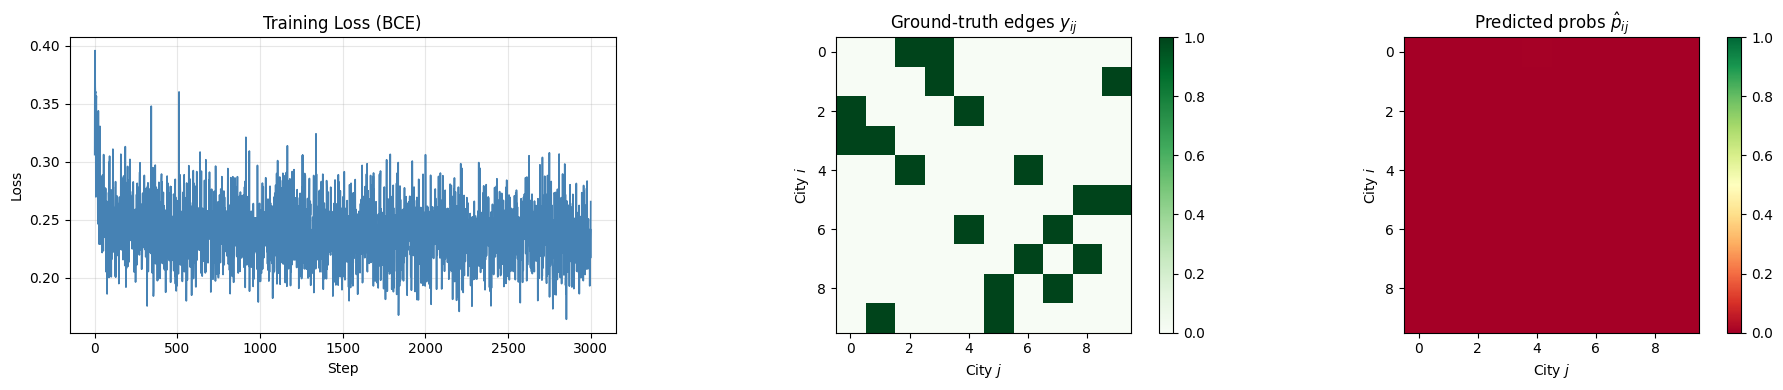

In [3]:
_loss_path = os.path.join(_HERE, 'model', 'losses.npy')
losses = np.load(_loss_path).tolist() if os.path.exists(_loss_path) else []

from data import (build_tsptwd_features, generate_time_windows,
                  generate_perturbations, optimal_tour_labels, greedy_decode)

# Probe instance for timing and visualisation
_coords_p = torch.rand(10, 2)
_tw_p, _svc_p = generate_time_windows(_coords_p, seed=0)
_perturbs_p   = generate_perturbations(10, total_time=_tw_p[:,1].max().item(), seed=0)
_nf_p, _ef_p  = build_tsptwd_features(_coords_p, _tw_p, _svc_p, _perturbs_p)
_nf_p = _nf_p.to(DEVICE); _ef_p = _ef_p.to(DEVICE)

# Warm-up + timing
with torch.no_grad():
    for _ in range(5):
        model(_nf_p, _ef_p)
_times = []
with torch.no_grad():
    for _ in range(50):
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(_nf_p, _ef_p)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        _times.append((time.perf_counter() - t0) * 1e3)

print(f'Parameters : {n_params:,}')
print(f'Inference  : {np.mean(_times):.3f} ms  (±{np.std(_times):.3f})  on {DEVICE}, n=10')
if losses:
    print(f'Training   : {len(losses)} steps   best loss {min(losses):.4f}')

# ── Plots ──────────────────────────────────────────────────────────────────────
_y_true = optimal_tour_labels(_coords_p)
with torch.no_grad():
    _p_hat = model(_nf_p, _ef_p).cpu()

_ncols = 3 if losses else 2
fig, axes = plt.subplots(1, _ncols, figsize=(6 * _ncols, 4))
_ax = iter(axes)

if losses:
    ax = next(_ax)
    ax.plot(losses, color='steelblue', lw=1.2)
    ax.set_title('Training Loss (BCE)')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

ax = next(_ax)
im = ax.imshow(_y_true.numpy(), cmap='Greens', vmin=0, vmax=1)
ax.set_title('Ground-truth edges $y_{ij}$')
ax.set_xlabel('City $j$'); ax.set_ylabel('City $i$')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = next(_ax)
im = ax.imshow(_p_hat.numpy(), cmap='RdYlGn', vmin=0, vmax=1)
ax.set_title('Predicted probs $\hat{p}_{ij}$')
ax.set_xlabel('City $j$'); ax.set_ylabel('City $i$')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_detail.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Benchmark — TSPTW-D

Datasets from `datasets/tsptwd_n{n}.json` (generated by `datasetsgenerator.ipynb`).

| Column | Description |
|--------|-------------|
| `travel_t` | Return time to depot $\tau_{\text{return}}$ |
| `penalty`  | Soft TW violation $\sum \lambda_i \max(0, \tau_i - b_i)$ |
| `next_day` | Cities pushed to next-day delivery |
| `obj`      | $Z(\sigma) = \text{travel\_t} + \text{penalty}$ |
| `gap%`     | Gap vs best algorithm on the same instance |
| `ms`       | Mean compute time over 20 runs |

**Algorithms**
- **GNN** — graph neural network (runs on `DEVICE`)
- **NN** — TW-aware nearest-neighbour (greedy, picks by actual dynamic cost)
- **2-opt** — local search seeded from NN tour, same objective as evaluator

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Benchmark helpers — run this cell before any benchmark cell below
# ══════════════════════════════════════════════════════════════════════════════
import json as _json
from data import build_tsptwd_features, greedy_decode


# ── Dataset loader ─────────────────────────────────────────────────────────────
def load_dataset(n):
    """Load datasets/tsptwd_n{n}.json → benchmark-ready dict (CPU tensors)."""
    path = os.path.join(DATASET_DIR, f'tsptwd_n{n}.json')
    with open(path, encoding='utf-8') as fh:
        d = _json.load(fh)
    scale = float(d['meta']['scale'])
    nodes = [d['depot']] + d['clients']
    coords = torch.tensor([[v['x'], v['y']] for v in nodes], dtype=torch.float32)
    tw     = torch.tensor([[v['a']/scale, v['b']/scale] for v in nodes], dtype=torch.float32)
    svc    = torch.tensor([v['service']/scale for v in nodes], dtype=torch.float32)
    perturbs = [
        (int(p['arc'][0]), int(p['arc'][1]),
         float(p['t_start'])/scale, float(p['t_end'])/scale,
         float(p['alpha']))
        for p in d.get('perturbations', [])
    ]
    nf, ef = build_tsptwd_features(coords, tw, svc, perturbs)
    return {'coords': coords, 'tw': tw, 'svc': svc,
            'perturbs': perturbs, 'nf': nf, 'ef': ef}


# ── Shared evaluator (same objective for ALL algorithms) ──────────────────────
def evaluate(coords, tour, tw, svc, perturbs,
             late_tol=LATE_TOL, penalty_coeff=1000.0):
    """
    Simulate a TSPTW-D tour and return (travel_time, penalty, obj, next_day_count).

    Next-day rule: arrival > b_i * (1 + late_tol)  →  t = H + a_i.
    Soft penalty : b_i < arrival <= b_i*(1+late_tol) → penalty += (t-b_i)*coeff.
    """
    horizon  = tw[0, 1].item()
    dist_mat = torch.cdist(coords, coords)
    t        = 0.0
    penalty  = 0.0
    next_day = 0

    for k in range(len(tour)):
        i = tour[k]
        j = tour[(k + 1) % len(tour)]

        if k > 0:
            a_i = tw[i, 0].item()
            b_i = tw[i, 1].item()
            if t < a_i:
                t = a_i
            elif t > b_i * (1.0 + late_tol):
                t = horizon + a_i
                next_day += 1
            elif t > b_i:
                penalty += (t - b_i) * penalty_coeff
            t += svc[i].item()

        base = dist_mat[i, j].item()
        mult = 1.0
        for pi, pj, ts, te, alpha in perturbs:
            if (pi == i and pj == j) or (pi == j and pj == i):
                if ts <= t <= te:
                    mult = max(mult, 1.0 + alpha)
        t += base * mult

    return t, penalty, t + penalty, next_day


# ── TW-aware nearest-neighbour ────────────────────────────────────────────────
def nn_tour_tw(coords, tw, svc, perturbs):
    """
    Greedy nearest-neighbour that accounts for dynamic costs, time windows,
    and the next-day rule at every step.

    At each position the algorithm picks the unvisited city that minimises
    the effective arrival time (after perturbations), preferring cities that
    do not trigger the next-day rule.
    """
    horizon  = tw[0, 1].item()
    dist_mat = torch.cdist(coords, coords)
    n        = coords.shape[0]
    visited  = torch.zeros(n, dtype=torch.bool)
    tour     = [0]; visited[0] = True
    t        = 0.0

    for _ in range(n - 1):
        cur      = tour[-1]
        best_j   = -1
        best_key = (2, float('inf'))   # (next_day_flag, effective_arrival)

        for j in range(n):
            if visited[j]:
                continue
            base = dist_mat[cur, j].item()
            mult = 1.0
            for pi, pj, ts, te, alpha in perturbs:
                if (pi == cur and pj == j) or (pi == j and pj == cur):
                    if ts <= t <= te:
                        mult = max(mult, 1.0 + alpha)
            arrival = t + base * mult
            a_j = tw[j, 0].item()
            b_j = tw[j, 1].item()

            if arrival > b_j * (1.0 + LATE_TOL):
                key = (1, horizon + a_j)   # next-day: penalise in sorting
            elif arrival < a_j:
                key = (0, a_j)
            else:
                key = (0, arrival)

            if key < best_key:
                best_key = key
                best_j   = j

        tour.append(best_j); visited[best_j] = True

        # Advance time to best_j
        base = dist_mat[cur, best_j].item()
        mult = 1.0
        for pi, pj, ts, te, alpha in perturbs:
            if (pi == cur and pj == best_j) or (pi == best_j and pj == cur):
                if ts <= t <= te:
                    mult = max(mult, 1.0 + alpha)
        t += base * mult
        a_j = tw[best_j, 0].item()
        b_j = tw[best_j, 1].item()
        if t > b_j * (1.0 + LATE_TOL):
            t = horizon + a_j
        elif t < a_j:
            t = a_j
        t += svc[best_j].item()

    return tour


# ── 2-opt local search ────────────────────────────────────────────────────────
def two_opt_tsptwd(coords, tour, tw, svc, perturbs, max_iter=300):
    """
    2-opt local search that optimises the same evaluate() objective.

    Uses first-improvement: accepts the first swap that reduces Z(sigma)
    and restarts the search from there.  Stops after max_iter passes with
    no improvement.
    """
    best      = list(tour)
    best_obj  = evaluate(coords, best, tw, svc, perturbs)[2]
    n         = len(tour)
    no_improve = 0

    while no_improve < max_iter:
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                candidate = best[:i] + best[i:j+1][::-1] + best[j+1:]
                obj = evaluate(coords, candidate, tw, svc, perturbs)[2]
                if obj < best_obj - 1e-9:
                    best     = candidate
                    best_obj = obj
                    improved = True
                    break
            if improved:
                break
        if improved:
            no_improve = 0
        else:
            no_improve += 1

    return best


# ── Run all three algorithms ──────────────────────────────────────────────────
def run_benchmark(inst, gnn_model, n_reps=N_REPS, two_opt_iter=300):
    """
    Run GNN (on DEVICE), TW-aware NN, and 2-opt on *inst*.
    Returns dict: {'gnn': {...}, 'nn': {...}, '2opt': {...}}.
    Each entry: travel, penalty, obj, next_day, ms, tour.
    """
    coords   = inst['coords']
    tw       = inst['tw']
    svc      = inst['svc']
    perturbs = inst['perturbs']
    nf       = inst['nf'].to(DEVICE)
    ef       = inst['ef'].to(DEVICE)

    results = {}

    # ── TW-aware NN ──────────────────────────────────────────────────────────
    nn_times = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        t_nn = nn_tour_tw(coords, tw, svc, perturbs)
        nn_times.append(time.perf_counter() - t0)
    tr, pen, obj, nd = evaluate(coords, t_nn, tw, svc, perturbs)
    results['nn'] = {'tour': t_nn, 'travel': tr, 'penalty': pen,
                     'obj': obj, 'next_day': nd,
                     'ms': float(np.mean(nn_times)) * 1e3}

    # ── 2-opt (seeded from NN) ────────────────────────────────────────────────
    t0     = time.perf_counter()
    t_2opt = two_opt_tsptwd(coords, t_nn, tw, svc, perturbs, max_iter=two_opt_iter)
    ms_2opt = (time.perf_counter() - t0) * 1e3
    tr, pen, obj, nd = evaluate(coords, t_2opt, tw, svc, perturbs)
    results['2opt'] = {'tour': t_2opt, 'travel': tr, 'penalty': pen,
                       'obj': obj, 'next_day': nd, 'ms': ms_2opt}

    # ── GNN (on DEVICE) ───────────────────────────────────────────────────────
    gnn_times = []
    with torch.no_grad():
        # Warm-up
        gnn_model(nf, ef)
        for _ in range(n_reps):
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            p_hat = gnn_model(nf, ef)
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            gnn_times.append(time.perf_counter() - t0)
    t_gnn = greedy_decode(p_hat.cpu())
    tr, pen, obj, nd = evaluate(coords, t_gnn, tw, svc, perturbs)
    results['gnn'] = {'tour': t_gnn, 'travel': tr, 'penalty': pen,
                      'obj': obj, 'next_day': nd,
                      'ms': float(np.mean(gnn_times)) * 1e3}

    return results


# ── Tour plot ─────────────────────────────────────────────────────────────────
def plot_tour(ax, coords, tour, tw, svc, perturbs, title='', max_label_n=50):
    """
    Directed TSPTW-D tour.  Red arc = perturbation active at traversal time.
    Node label: id and time window [a_i, b_i].
    """
    xy       = coords.numpy()
    n        = len(tour)
    dist_mat = torch.cdist(coords, coords)
    t        = 0.0
    arc_colors = []

    for k in range(n):
        i = tour[k]; j = tour[(k + 1) % n]
        if k > 0:
            a_i = tw[i, 0].item()
            if t < a_i:
                t = a_i
            t += svc[i].item()
        color = 'steelblue'; mult = 1.0
        for pi, pj, ts, te, alpha in perturbs:
            if (pi == i and pj == j) or (pi == j and pj == i):
                if ts <= t <= te:
                    color = 'red'; mult = max(mult, 1.0 + alpha)
        arc_colors.append(color)
        t += dist_mat[i, j].item() * mult

    for k in range(n):
        i = tour[k]; j = tour[(k + 1) % n]
        ax.annotate('', xy=(xy[j,0], xy[j,1]), xytext=(xy[i,0], xy[i,1]),
                    arrowprops=dict(arrowstyle='->', color=arc_colors[k],
                                   lw=1.8, alpha=0.85))

    ax.scatter(xy[:,0], xy[:,1], s=120, zorder=5, color='black')
    if n <= max_label_n:
        for idx, (xi, yi) in enumerate(xy):
            a_i = tw[idx, 0].item(); b_i = tw[idx, 1].item()
            ax.annotate(f'{idx}\n[{a_i:.2f},{b_i:.2f}]',
                        (xi + 0.015, yi + 0.015), fontsize=8, color='#333333')

    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.05, 1.10); ax.set_ylim(-0.05, 1.10)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)


# ── Display results ───────────────────────────────────────────────────────────
def show_results(n, results, inst):
    """Print table + 2x3 figure for one benchmark run."""
    algos  = ['gnn', 'nn', '2opt']
    labels = {'gnn': 'GNN', 'nn': 'NN (TW-aware)', '2opt': '2-opt'}
    colors = {'gnn': 'steelblue', 'nn': 'tomato', '2opt': 'seagreen'}

    best_obj = min(r['obj'] for r in results.values())

    # Text table
    hdr = (f"{'algo':<14}  {'travel_t':>10}  {'penalty':>10}"
           f"  {'next_day':>8}  {'obj':>10}  {'gap%':>8}  {'ms':>10}")
    print(f'\n── n = {n} ──────────────────────────────────────────────────────')
    print(hdr); print('─' * len(hdr))
    for a in algos:
        r   = results[a]
        gap = (r['obj'] - best_obj) / max(best_obj, 1e-9) * 100
        print(f"{labels[a]:<14}  {r['travel']:>10.4f}  {r['penalty']:>10.2f}"
              f"  {r['next_day']:>8d}  {r['obj']:>10.2f}"
              f"  {gap:>+8.1f}%  {r['ms']:>10.3f}")

    # Figure: 2 rows × 3 cols
    fig, axes = plt.subplots(2, 3, figsize=(20, 14))
    fig.suptitle(
        f'TSPTW-D Benchmark — n = {n}  |  device: {DEVICE}  |  next-day rule: >5% late',
        fontsize=12)

    x = np.arange(len(algos)); w = 0.5
    xlabels = [labels[a] for a in algos]

    # [0,0] Stacked bar: travel + penalty
    travels   = [results[a]['travel']  for a in algos]
    penalties = [results[a]['penalty'] for a in algos]
    bars = axes[0,0].bar(x, travels, w,
                         color=[colors[a] for a in algos], edgecolor='white', alpha=0.9)
    axes[0,0].bar(x, penalties, w, bottom=travels,
                  color=[colors[a] for a in algos], edgecolor='white', alpha=0.45, hatch='//')
    axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(xlabels)
    axes[0,0].set_ylabel('Objective value')
    axes[0,0].set_title('Objective (solid=travel, hatch=TW penalty)')
    axes[0,0].grid(axis='y', alpha=0.3)
    for bar, a in zip(bars, algos):
        r   = results[a]
        gap = (r['obj'] - best_obj) / max(best_obj, 1e-9) * 100
        top = r['travel'] + r['penalty']
        axes[0,0].text(bar.get_x() + bar.get_width()/2, top + max(travels)*0.02,
                       f"obj={r['obj']:.2f}\ngap={gap:+.1f}%",
                       ha='center', va='bottom', fontsize=8)

    # [0,1] Next-day count
    nd_vals = [results[a]['next_day'] for a in algos]
    axes[0,1].bar(x, nd_vals, w,
                  color=[colors[a] for a in algos], edgecolor='white', alpha=0.85)
    axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(xlabels)
    axes[0,1].set_ylabel('Count')
    axes[0,1].set_title('Next-day deliveries')
    axes[0,1].grid(axis='y', alpha=0.3)
    for xi, (a, nd) in enumerate(zip(algos, nd_vals)):
        axes[0,1].text(xi, nd + 0.05, str(nd), ha='center', va='bottom', fontsize=10)

    # [0,2] Computation time
    ms = [results[a]['ms'] for a in algos]
    axes[0,2].bar(x, ms, w, color=[colors[a] for a in algos], edgecolor='white', alpha=0.85)
    axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(xlabels)
    axes[0,2].set_ylabel('ms')
    axes[0,2].set_title('Computation time')
    axes[0,2].grid(axis='y', alpha=0.3)
    for xi, (a, m) in enumerate(zip(algos, ms)):
        axes[0,2].text(xi, m + max(ms)*0.01, f'{m:.2f}', ha='center', va='bottom', fontsize=9)

    # [1,0] GNN tour  [1,1] NN tour  [1,2] 2-opt tour
    for col, a in enumerate(algos):
        r   = results[a]
        gap = (r['obj'] - best_obj) / max(best_obj, 1e-9) * 100
        plot_tour(axes[1, col], inst['coords'], r['tour'],
                  inst['tw'], inst['svc'], inst['perturbs'],
                  title=(f"{labels[a]}  obj={r['obj']:.2f}"
                         f"  gap={gap:+.1f}%  next_day={r['next_day']}"))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'benchmark_n{n}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: benchmark_n{n}.png')


print('Helpers loaded.')
print('  load_dataset(n)                              -- load JSON dataset')
print('  run_benchmark(inst, model, two_opt_iter=300) -- GNN + NN + 2-opt')
print('  show_results(n, results, inst)               -- table + charts')
print(f'  Running on: {DEVICE}')


Helpers loaded.
  load_dataset(n)                              -- load JSON dataset
  run_benchmark(inst, model, two_opt_iter=300) -- GNN + NN + 2-opt
  show_results(n, results, inst)               -- table + charts
  Running on: cpu


### n = 10 cities


── n = 10 ──────────────────────────────────────────────────────
algo              travel_t     penalty  next_day         obj      gap%          ms
──────────────────────────────────────────────────────────────────────────────────
GNN                 4.1029        0.00         8        4.10     +27.9%      46.269
NN (TW-aware)       6.9152        0.00         0        6.92    +115.6%       2.822
2-opt               3.2073        0.00         9        3.21      +0.0%    6779.804


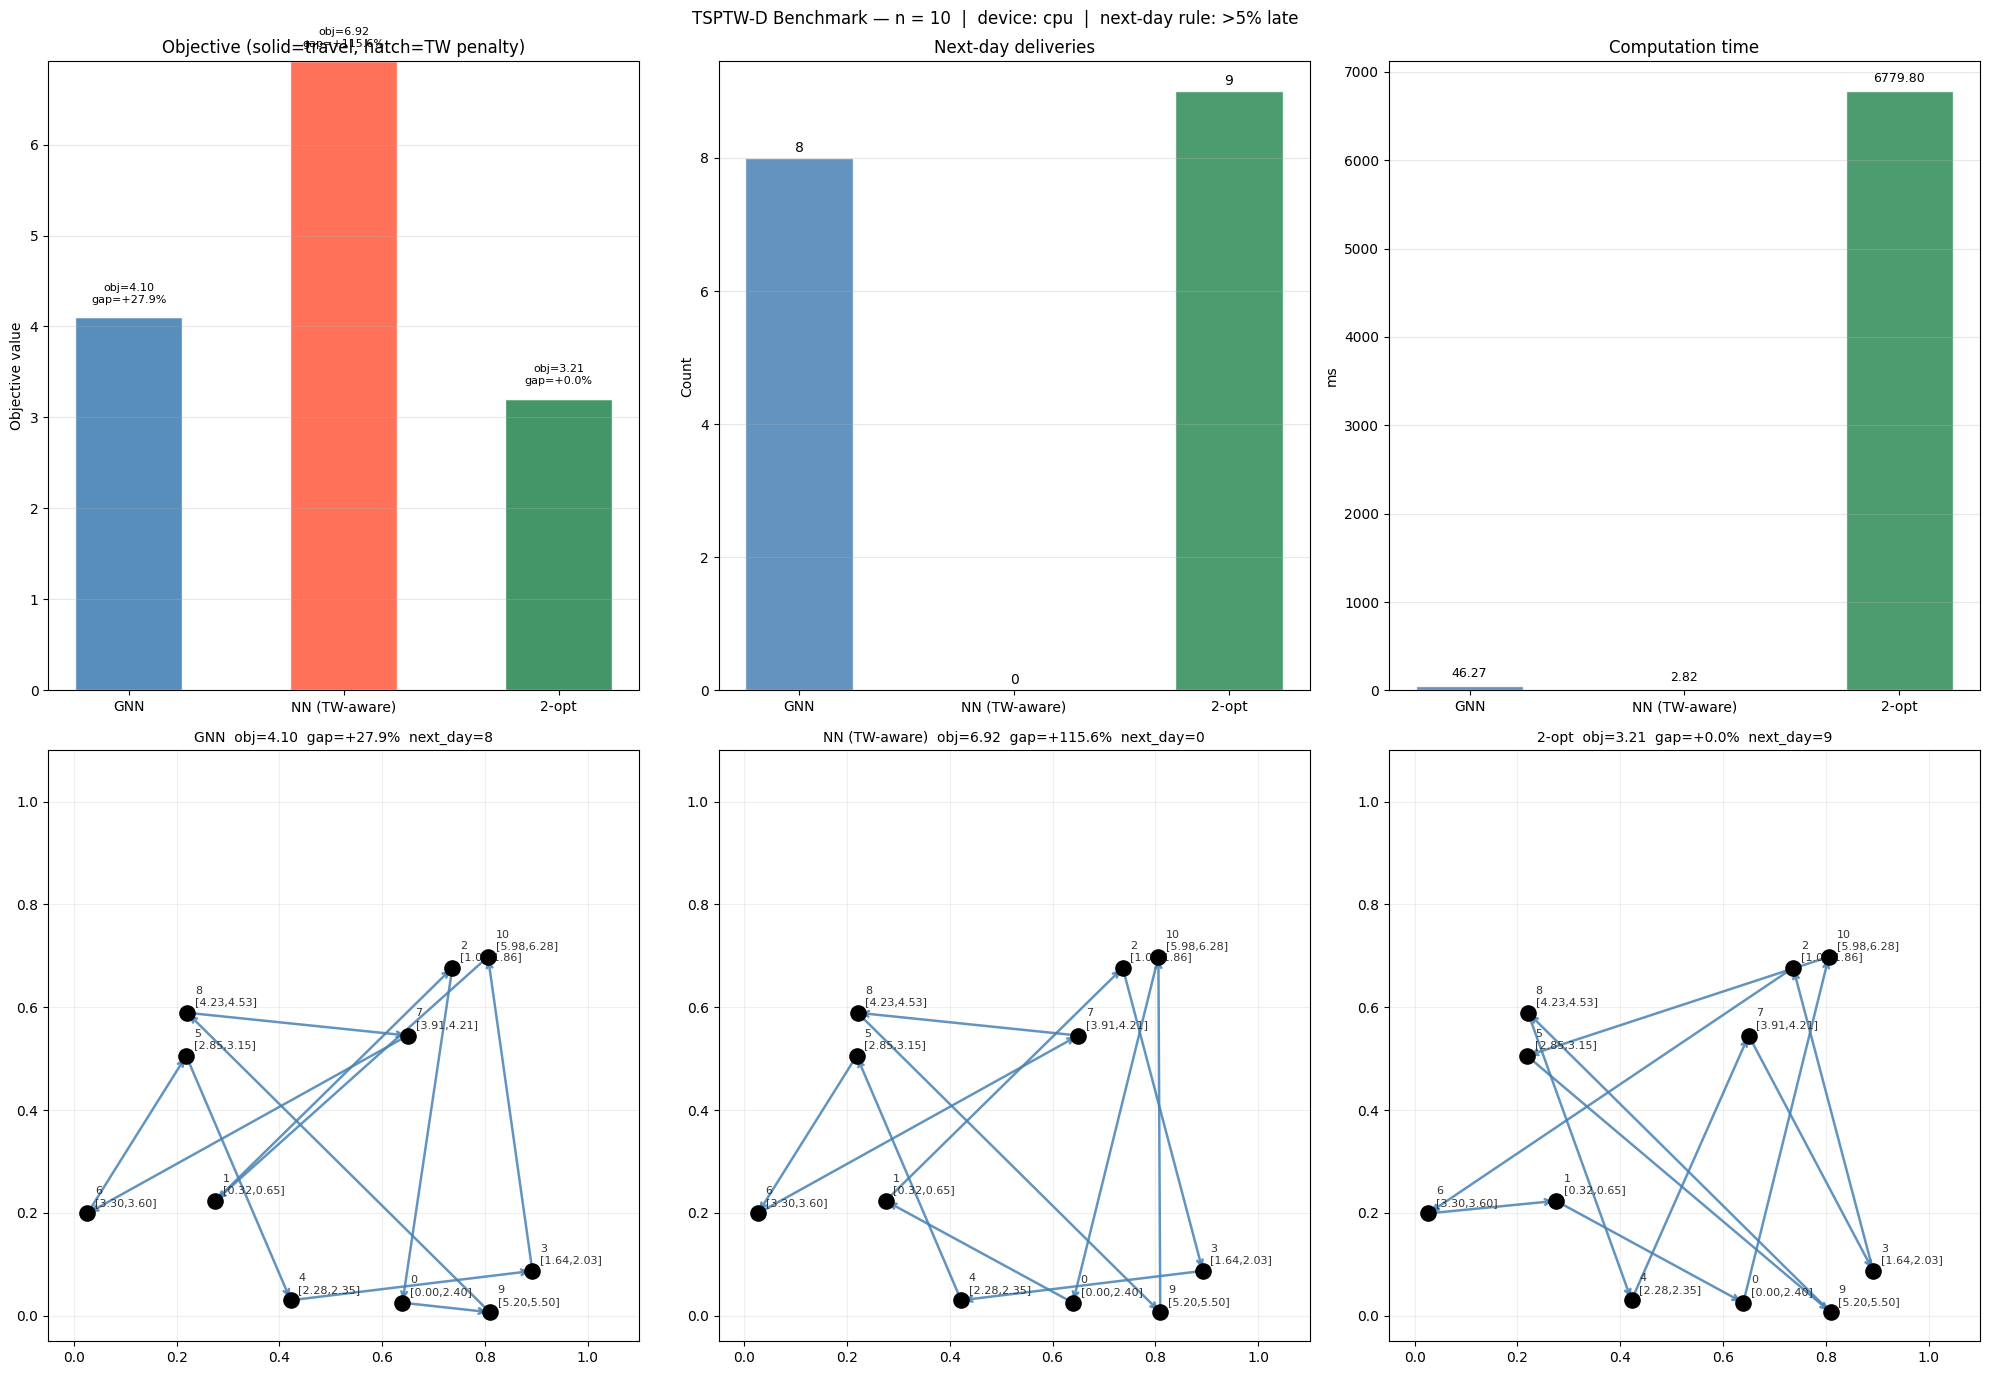

Saved: benchmark_n10.png


In [5]:
inst_10    = load_dataset(10)
results_10 = run_benchmark(inst_10, model, two_opt_iter=500)
show_results(10, results_10, inst_10)


### n = 50 cities

In [ ]:
inst_50    = load_dataset(50)
results_50 = run_benchmark(inst_50, model, two_opt_iter=300)
show_results(50, results_50, inst_50)


### n = 100 cities

In [ ]:
inst_100    = load_dataset(100)
results_100 = run_benchmark(inst_100, model, two_opt_iter=150)
show_results(100, results_100, inst_100)


### n = 200 cities

In [ ]:
inst_200    = load_dataset(200)
results_200 = run_benchmark(inst_200, model, two_opt_iter=75)
show_results(200, results_200, inst_200)
